<a href="https://colab.research.google.com/github/PMSense/AI-Security-/blob/main/Slam_Laqtib_project2_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 2: Digit Classification Naive Bayes

**Solution**

# Intro
---
In this project, you'll continue working on your own image recognition system for classifying digits. Read through the code and the instructions carefully and add your own code where indicated. Each problem can be addressed succinctly with the included packages -- please don't add any more.
As always, you're welcome to work on the project in groups and discuss ideas over Slack, but <b> please prepare your own write-up (with your own code). </b>


## Grading
---
 - Make sure to answer every part in every question.
 - There are 6 questions, each equally weighted and an additional bonus question.
 - The extra credit question will be graded based on your attempts at feature engineering and resulting improved accuracy.
 - Read carefully what is asked including the notes.
 - Additional points may be deducted if:
   - the code is not clean, well commented,
  -  if the functions or answers are too long.

## Requirements:
---
1. Comment your code.
1. All graphs should have titles, label for each axis, and if needed a legend. It should be understandable on its own.
1. All code must run on colab.research.google.com
1. You should not import any additional libraries.
1. Try and minimize the use of the global namespace (meaning keep things in functions).

## Additional Reading and notes
---
If you're interested, check out these links related to digit recognition:

* Yann Lecun's MNIST benchmarks: http://yann.lecun.com/exdb/mnist/
* Stanford Streetview research and data: http://ufldl.stanford.edu/housenumbers/

Finally, if you'd like to get started with Tensorflow, you can read through this tutorial: https://www.tensorflow.org/tutorials/keras/basic_classification. It uses a dataset called "fashion_mnist", which is identical in structure to the original digit mnist, but uses images of clothing rather than images of digits. The number of training examples and number of labels is the same. In fact, you can simply replace the code that loads "fashion_mnist" with "mnist" and everything should work fine.

In [ ]:
# This tells matplotlib not to try opening a new window for each plot.
%matplotlib inline

# Import a bunch of libraries.
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from sklearn.pipeline import Pipeline
from sklearn.datasets import fetch_openml
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LinearRegression
from sklearn.naive_bayes import BernoulliNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

# Set the randomizer seed so results are the same each time.
np.random.seed(0)

In [ ]:
import sklearn
sklearn.__version__

'1.6.1'

Load the data. Notice that the data gets partitioned into training, development, and test sets. Also, a small subset of the training data called mini_train_data and mini_train_labels gets defined, which you should use in all the experiments below, unless otherwise noted.

In [ ]:
# Load the digit data from https://www.openml.org/d/554 or from default local location '~/scikit_learn_data/...'
X, Y = fetch_openml(name='mnist_784', return_X_y=True, cache=False)

# Rescale grayscale values to [0,1].
X = X / 255.0

# Shuffle the input: create a random permutation of the integers between 0 and the number of data points and apply this
# permutation to X and Y.
# NOTE: Each time you run this cell, you'll re-shuffle the data, resulting in a different ordering.
shuffle = np.random.permutation(np.arange(X.shape[0]))
X, Y = X.iloc[shuffle], Y.iloc[shuffle]

print('data shape: ', X.shape)
print('label shape:', Y.shape)

# Set some variables to hold test, dev, and training data.
test_data, test_labels = X[61000:], Y[61000:]
dev_data, dev_labels = X[60000:61000], Y[60000:61000]
train_data, train_labels = X[:60000], Y[:60000]
mini_train_data, mini_train_labels = X[:1000], Y[:1000]



data shape:  (70000, 784)
label shape: (70000,)


### Question 1: Applying a smoothing using numpy.
---

A common image processing technique is to smooth an image by **blurring**. The idea is that the value of a particular pixel is estimated as the weighted combination of the original value and the values around it. Typically, the blurring is Gaussian, i.e., the weight of a pixel's influence is determined by a Gaussian function over the distance to the relevant pixel.

1. Implement a simplified Gaussian blur filter by just using the 8 neighboring pixels like this: the smoothed value of a pixel is a weighted combination of the original value and the 8 neighboring values.
1. Choose some weights as a starting point. Produce and evaluate four 1-Nearest Neighbor models by applying your blur filter in these ways:
  1. Do not use the filter
  1. Filter the training data but not the dev data
  1. Filter the dev data but not the training data
  1. Filter both training data and dev data
1. Show the accuracies of the four models evaluated as described. What do you see? Can you explain why this is?
1. Experiment with weights that makes one model's accuracy at least 0.9.

Notes:
* Train on the (filtered) mini train set.
* Evaluate performance on the (filtered) dev set.
* A good trick to simplify your code is to use numpy's pad function to add 0s around your original array so you don't have to deal with "edge cases".
* In addition, you can use numpy to multiply and sum slices of two arrays.
* [This notebook](https://colab.research.google.com/drive/1eJXTQLtREXQjQIsLOA9uCrBl6B049-pO) might help shows some example numpy code.
* In general, [numpy operations will be much faster than for loops](https://colab.research.google.com/drive/1KJI4JtuIqVdyZHTTe_mAlKYA5XdLFp3_).
* There are other Guassian blur filters available, for example in `scipy.ndimage.filters`. You are welcome to experiment with those, but in this question, please implement your own.

In [ ]:
# Function definition, takes image data and a 3x3 kernel as input.  It's 3x3 array filled with the neighbor weight
def blur(data, kernel):
    # Ensure the kernel is a numpy array for efficient math operations, and check that the kernel is the correct 3x3 shape
    kernel = np.array(kernel)
    if kernel.shape != (3, 3): raise ValueError("Kernel must be a 3x3 array.")
    # Convert the input data (which might be a pandas DataFrame) to a numpy array
    data_np = data.to_numpy() if isinstance(data, pd.DataFrame) else data
    # First creates an empty list to store the new, blurred images, then loops through each 784 pixels image in the dataset and reshape it into a 2D 28x28 grid
    blurred_images = []
    for image_flat in data_np:
        image_2d = image_flat.reshape(28, 28)
        # Add a 1 pixel border of zeros around the 28x28 image. This makes it a 30x30 grid, which simplifies applying the kernel at the edges.
        padded_image = np.pad(image_2d, pad_width=1, mode='constant', constant_values=0)
        blurred_image_2d = np.zeros((28, 28)) # Creates a new, empty 28x28 grid to store the output pixels.

        # Loop through each row (r) and column (c) of the output image.
        for r in range(28):
            for c in range(28):
                neighborhood = padded_image[r:r+3, c:c+3] # Extracts the corresponding 3x3 neighborhood from the padded image.
                # This is the real blurring step: 1) it multiplies the 3x3 neighborhood by the 3x3 kernel, 2) it sums up the 9 resulting products to get the new pixel value.
                blurred_image_2d[r, c] = np.sum(neighborhood * kernel)

        # Flatten the 28x28 blurred grid back into a 784-pixel array and adds it to the list.
        blurred_images.append(blurred_image_2d.flatten())
    return np.array(blurred_images)  # Convert the list of blurred images into a single numpy array and returns it.


# Function definition for our main experiment
def Q1():

    ### STUDENT START ###

    # Initial Model Evaluation:

    # Let's define the weights for the initial 3x3 blur kernel: First, the center pixel gets a weight of 0.5,
    # while the remaining 0.5 weight is distributed evenly among the 8 neighbors.
    initial_weight_center = 0.5
    initial_weight_neighbor = (1 - initial_weight_center) / 8.0

    # Let's create a 3x3 array filled with the neighbor weight. For any single pixel, the 3x3 area represents the pixel itself (at the center) and
    # the eight pixels that are directly touching it horizontally, vertically, and diagonally.
    initial_kernel = np.full((3, 3), initial_weight_neighbor)
    initial_kernel[1, 1] = initial_weight_center # set the middle element to the center weight.

    # Apply the blur filter to the training and development (dev) datasets using the kernel defined above.
    filtered_mini_train = blur(mini_train_data, initial_kernel)
    filtered_dev = blur(dev_data, initial_kernel)

    # Initialize the 1-Nearest Neighbors classifier model and show the accuracies of the four models evaluated as described.
    knn = KNeighborsClassifier(n_neighbors=1)

    #  Model 1 — No filter:
    knn.fit(mini_train_data.to_numpy(), mini_train_labels) # Trains the model on the original, unfiltered training data.
    acc_none = knn.score(dev_data.to_numpy(), dev_labels)  # Evaluates its accuracy on the original, unfiltered dev data.
    # Model 2 — Filter training data only:
    knn.fit(filtered_mini_train, mini_train_labels) # Train on blurred data...
    acc_train_only = knn.score(dev_data.to_numpy(), dev_labels) # and test on sharp data.
    # Model 3 — Filter dev data only:
    knn.fit(mini_train_data.to_numpy(), mini_train_labels) # Train on sharp data
    acc_dev_only = knn.score(filtered_dev, dev_labels) #   # and test on blurred data.
    # Model 4 – Filter both training and dev data:
    knn.fit(filtered_mini_train, mini_train_labels) # Train on blurred data
    acc_both = knn.score(filtered_dev, dev_labels)  # and test on blurred data.


    # Print the results from the four experiments.
    print("\n1. Accuracies of the Four Models:")
    print(f"\tAccuracy with no filter:\t\t{acc_none:.3f}")
    print(f"\tAccuracy with train data only:\t\t{acc_train_only:.3f}")
    print(f"\tAccuracy with dev data only:\t\t{acc_dev_only:.3f}")
    print(f"\tAccuracy with both train and dev data : {acc_both:.3f}")


    # Experimenting with different weights:
    weights = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
    print(f"\n2. Experimenting with Weights {weights} for > 0.9 Accuracy:\n")

    for optimized_weight_center in weights:
      # Defines a new, "optimized" kernel. This one gives the center pixel different weights ..0.1, 0.2, 0.3, 0.4..
      optimized_weight_neighbor = (1 - optimized_weight_center) / 8.0
      optimized_kernel = np.full((3, 3), optimized_weight_neighbor)
      optimized_kernel[1, 1] = optimized_weight_center
      # Let's filter the data again using this new blur kernel.
      filtered_mini_train_opt = blur(mini_train_data, optimized_kernel)
      filtered_dev_opt = blur(dev_data, optimized_kernel)
      # and let's retrain and evaluate the "Blur of Both" in Model with the newly filtered data.
      knn.fit(filtered_mini_train_opt, mini_train_labels)
      acc_both_optimized = knn.score(filtered_dev_opt, dev_labels)
      print(f"\tAccuracy with optimized kernel with weight center {optimized_weight_center}:\t {acc_both_optimized:.4f}")


  ### STUDENT END ###

Q1()


1. Accuracies of the Four Models:
	Accuracy with no filter:		0.884
	Accuracy with train data only:		0.904
	Accuracy with dev data only:		0.875
	Accuracy with both train and dev data : 0.899

2. Experimenting with Weights [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9] for > 0.9 Accuracy:

	Accuracy with optimized kernel with weight center 0.01:	 0.9040
	Accuracy with optimized kernel with weight center 0.05:	 0.9040
	Accuracy with optimized kernel with weight center 0.1:	 0.9050
	Accuracy with optimized kernel with weight center 0.2:	 0.9010
	Accuracy with optimized kernel with weight center 0.3:	 0.9000
	Accuracy with optimized kernel with weight center 0.4:	 0.8990
	Accuracy with optimized kernel with weight center 0.5:	 0.8990
	Accuracy with optimized kernel with weight center 0.6:	 0.8960
	Accuracy with optimized kernel with weight center 0.7:	 0.8970
	Accuracy with optimized kernel with weight center 0.8:	 0.8900
	Accuracy with optimized kernel with weight center 0.9:	 

ANSWER:

**1. Accuracies of the Four Models:**


- **Best Performance**: The highest accuracy was achieved when only the training data was blurred.

- **Worst Performance**: Filtering only the development data produced the lowest accuracy, performing worse than doing no filtering at all.

- **Good Performance**: Blurring both the training and development sets was better than the baseline but not as effective as blurring the training data alone.

Reasoning:

- **Why Blurring Works?**: The filter smooths images, reducing noise and forcing the model to learn the general, essential shapes of the digits instead of memorizing minor pixel details.

- **Why Mismatches Fail?**: The worst result occurred due to a data mismatch. The model, trained on sharp images, could not effectively recognize the unfamiliar, blurry images in the development set.

**2. Experimenting with Weights**:

The results clearly show that a stronger blur significantly improves our model's accuracy, but only up to a certain point.
The core reason is that the blur simplifies the images, forcing your 1-Nearest Neighbor (1-NN) model to generalize better by ignoring noise.
The results show a clear trend: as the center weight decreases from 0.9 to 0.1, the accuracy increases from 0.8870 to 0.9050.
Notice: The accuracy peaks at 0.9050 (with a weight of 0.1) and then stays flat or slightly decreases for weights of 0.05 and 0.01. Implies dimininishing returns.



### Question 2: Modeling your data and experimenting with different Naive Bayes models.
---

1. Produce two Naive Bayes models and evaluate their performances.  Recall that Naive Bayes estimates P(feature|label), where each label is a categorical, not a real number.
  1. For the first model, map pixel values to either 0 or 1, representing white or black - you should pre-process the data or use `BernoulliNB`'s `binarize` parameter to set the white/black separation threshold to 0.1.  Use `BernoulliNB` to produce the model.
  1. For the second model, map pixel values to either 0, 1, or 2, representing white, gray, or black - you should pre-process the data, seting the white/gray/black separation thresholds to 0.1 and 0.9.  Here you'll likely need to implement a `trianarize` helper function. Since we are going beyond the binary representation of our features, you should use `MultinomialNB` to produce the model.
1. Show the Bernoulli model accuracy and the Multinomial model accuracy.
1. Does the multinomial version improve the results? Why or why not?

Notes:
* Train on the mini train set.
* Evaluate performance on the dev set.



In [ ]:
"""
  We plan to train and evaluate Bernoulli and Multinomial Naive Bayes models on the MNIST dataset
"""

def trianarize_data(data, lower_thresh, upper_thresh):
  """
  This is a MultinomialNB helper function that converts pixel values into three discrete categories (0, 1, 2).
    - Values <= lower_thresh map to 0 (white)
    - Values between lower_thresh and upper_thresh map to 1 (gray)
    - Values > upper_thresh map to 2 (black)
    np.digitize is a highly efficient way to perform this binning.
"""
  data_np = data.to_numpy() if isinstance(data, pd.DataFrame) else data # Ensure data is a numpy array for processing
  bins = [lower_thresh, upper_thresh]
  return np.digitize(data_np, bins=bins)


def Q2():

    print()
    print("Model 1 — Training Bernoulli Naive Bayes Model:")
    # Solution with binarization by explicit binarize function
    # Instantiate the BernoulliNB classifier. The `binarize=0.1` parameter tells the model to internally convert all feature
    # values > 0.1 to 1, and all others to 0, directly handling the preprocessing.
    bernoulli_model = BernoulliNB(binarize=0.1)
    bernoulli_model.fit(mini_train_data.to_numpy(), mini_train_labels) # Training the model on the original mini training data.
    bernoulli_accuracy = bernoulli_model.score(dev_data.to_numpy(), dev_labels) # Evaluating the model's performance on the development set.
    print(f"\t\tBernoulli Model Accuracy: {bernoulli_accuracy:.4f}\n")


    print("Model 2 - Training Multinomial Naive Bayes Model:")
    # Pre-process the training and dev data using the trianarize helper function. The thresholds are set to 0.1 and 0.9 as requested.
    mini_train_trianarized = trianarize_data(mini_train_data, 0.1, 0.9)
    dev_data_trianarized = trianarize_data(dev_data, 0.1, 0.9)
    multinomial_model = MultinomialNB()
    multinomial_model.fit(mini_train_trianarized, mini_train_labels)
    multinomial_accuracy = multinomial_model.score(dev_data_trianarized, dev_labels) # Evaluate the model's performance on the trianarized development set.
    print(f"\t\tMultinomial Model Accuracy: {multinomial_accuracy:.4f}\n")


Q2()


Model 1 — Training Bernoulli Naive Bayes Model:
		Bernoulli Model Accuracy: 0.8140

Model 2 - Training Multinomial Naive Bayes Model:
		Multinomial Model Accuracy: 0.8070




ANSWER:

- No, the multinomial version did not improve the results (0.8070 vs 0.8140).


**Summary**

- **Multinomial Naive Bayes (MNB)**: This model is designed for count-based features (like word frequencies), but the trinarized pixel values (0, 1, 2) represent intensity levels, creating a fundamental mismatch with the model's assumptions.

- **Bernoulli Naive Bayes (BNB)**: This model is built for binary features (0 or 1), making it a much more natural and effective fit for the binarized black and white pixel data.

- **Why Simpler Won?**: The extra "gray" detail from trinarization didn't improve performance because the added complexity and arbitrary thresholds didn't provide enough useful information to be worthwhile.

**Conclusion**: The Bernoulli model is the better choice for this task because its design aligns more closely with the nature of the binarized image data.

### Question 3: Applying the grid search technique.
1. Search across several values of the LaPlace smoothing parameter (alpha) to find its effect on a Bernoulli Naive Bayes model's performance.  Show the accuracy at each alpha value.
1. What is the best value for alpha? What is the accuracy when alpha is near 0? Is this what you'd expect?

Notes:
* Set binarization threshold to 0.
* Train on the mini train set.
* Evaluate performance by 5-fold cross-validation.
* Use `GridSearchCV(..., ..., cv=..., scoring='accuracy', iid=False)` to vary alpha and evaluate performance by cross-validation.
* Cross-validation is based on partitions of the training data, so results will be a bit different than if you had used the dev set to evaluate performance.



In [ ]:
"""
  We perform a grid search to find the optimal alpha for a Bernoulli Naive Bayes model.
  Args: alpha: A dictionary where the <key> is 'alpha' and the 'value' is a 'list of alpha values to test'.
"""

def Q3(alphas):

    print("Performing Grid Search for BernoulliNB Alpha...")

    # Instantiate the model. The binarize=0.0 parameter ensures that any pixel value > 0 is treated as 1 (on), and pixels with a value of 0 are treated as 0 (off).
    model = BernoulliNB(binarize=0.0)

    # Instantiate GridSearchCV. This will search over the provided 'alphas', using 5-fold cross-validation to evaluate the accuracy for each alpha value.
    grid_search = GridSearchCV(estimator=model, param_grid=alphas, cv=5, scoring='accuracy')
    grid_search.fit(mini_train_data.to_numpy(), mini_train_labels)     # Fit the grid search to the mini training data

    # Extracting and displaying the results
    print("\nCross-validation results for each alpha value:")
    for alpha, mean_score in zip(grid_search.cv_results_['param_alpha'], grid_search.cv_results_['mean_test_score']):
        print(f"\t Alpha: {alpha:<10} Mean CV Accuracy: {mean_score:.4f}")

    print("\nAnalysing our Results - reporting the best alpha and its accuracy:")
    best_alpha = grid_search.best_params_['alpha']
    best_accuracy = grid_search.best_score_
    print(f"\t - The best value for alpha is: {best_alpha}")
    print(f"\t - This alpha achieves a mean cross-validation accuracy of: {best_accuracy:.4f}")

    # 6. Analyze the near-zero alpha case
    near_zero_accuracy = grid_search.cv_results_['mean_test_score'][0]
    print(f"\t - The accuracy when alpha is near 0 (1.0e-10) is: {near_zero_accuracy:.4f}")


# The alpha values to be tested by GridSearchCV
alphas = {'alpha': [1.0e-10, 0.0001, 0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 10.0]}
Q3(alphas)

Performing Grid Search for BernoulliNB Alpha...

Cross-validation results for each alpha value:
	 Alpha: 1e-10      Mean CV Accuracy: 0.8140
	 Alpha: 0.0001     Mean CV Accuracy: 0.8190
	 Alpha: 0.001      Mean CV Accuracy: 0.8250
	 Alpha: 0.01       Mean CV Accuracy: 0.8220
	 Alpha: 0.1        Mean CV Accuracy: 0.8180
	 Alpha: 0.5        Mean CV Accuracy: 0.8130
	 Alpha: 1.0        Mean CV Accuracy: 0.8090
	 Alpha: 2.0        Mean CV Accuracy: 0.8050
	 Alpha: 10.0       Mean CV Accuracy: 0.7830

Analysing our Results - reporting the best alpha and its accuracy:
	 - The best value for alpha is: 0.001
	 - This alpha achieves a mean cross-validation accuracy of: 0.8250
	 - The accuracy when alpha is near 0 (1.0e-10) is: 0.8140


ANSWER:


**Is this what you'd expect?**: Yes.
This lower accuracy is entirely expected. The alpha parameter controls Laplace (or additive) smoothing. Its purpose is to handle the "zero-frequency problem."

**Alpha Near 0 (e.g., 1e-10):**

- The smoothing effect is minimal, causing the model to overfit to the training data.

- Unseen feature combinations are assigned a probability near zero, which hurts the model's ability to generalize to new data.

- This results in lower, suboptimal accuracy.

**Optimal Alpha (e.g., 0.01):**

- This provides a balanced amount of smoothing.

- It's just enough to prevent zero probability issues, allowing the model to handle rare or unseen features gracefully.

- This leads to the highest accuracy by improving generalization without distorting the learned data patterns.

**Larger Alpha (e.g., > 1.0):**

- The smoothing becomes too aggressive.

- It flattens the probability distributions, making all classes appear more similar to each other.

- This makes it harder for the model to distinguish between classes, causing accuracy to drop.

### Question 4: Experimenting with Gaussian Naive Bayes
---
1. Produce a model using Guassian Naive Bayes, which is intended for real-valued features, and evaluate performance. You will notice that it does not work so well.
1. Diagnose and explain the problem.
1. Apply a simple fix so that the model accuracy is around the same as for a Bernoulli Naive Bayes model.
1. Show the model accuracy before your fix and the model accuracy after your fix.  
1. Explain your solution.

Notes:
* Train on the mini train set.
* Evaluate performance on the dev set.
* Take a look at var_smoothing argument for GaussianNB.
* Feel free to  examine theta and sigma to better understand what's happening. In general though, **it is not a good idea to mess with internal variables of the model**. These are stored in the model's `theta_` and `sigma_` attributes.

In [ ]:
"""
  Train and evaluate a Gaussian Naive Bayes model, diagnose a problem with its
  performance, and apply a simple fix using var_smoothing.
"""

def Q4():

    print("Evaluating Gaussian Naive Bayes prior to the simple fix...")
    gnb_before = GaussianNB() # instantiate default GaussianNB model
    gnb_before.fit(mini_train_data.to_numpy(), mini_train_labels) # training GaussianNB model
    accuracy_before = gnb_before.score(dev_data.to_numpy(), dev_labels) # Evaluate its performance on the dev set.
    print(f"\tModel accuracy before fix: {accuracy_before:.4f}\n")

    print("Evaluating Gaussian Naive Bayes (After Fix)...")
    # The fix is to use the `var_smoothing` parameter. This adds a small, specified
    # value to the variance of all features, ensuring that no feature has zero variance.
    # A value of 0.01 to 0.1 often works well for this dataset.
    var_smoothing_value = 0.05
    gnb_after = GaussianNB(var_smoothing=var_smoothing_value)
    gnb_after.fit(mini_train_data.to_numpy(), mini_train_labels)# Train and evaluate the improved model.
    accuracy_after = gnb_after.score(dev_data.to_numpy(), dev_labels)
    print(f"\tModel accuracy after fix (with var_smoothing={var_smoothing_value}): {accuracy_after:.4f}\n")

Q4()

Evaluating Gaussian Naive Bayes prior to the simple fix...
	Model accuracy before fix: 0.5930

Evaluating Gaussian Naive Bayes (After Fix)...
	Model accuracy after fix (with var_smoothing=0.05): 0.8160



ANSWER:


**Problem**:

- Assumption Mismatch: Gaussian Naive Bayes (GNB) assumes features follow a bell-curve distribution, but pixel data is often either "on" or "off".

- Zero Variance: With small datasets, some pixels may have the same value for all samples in a class, leading to a variance of zero.

- Mathematical Instability: The GaussianNB formula involves dividing by variance, so a zero variance feature causes "divide-by-zero" errors and produces unreliable results.

**Solution**:

- Use var_smoothing: This parameter in the GaussianNB model adds a small, positive value to the variance of every feature.

- Function: It acts as a form of regularization, preventing the model from failing on features with no variance.

**Reasoning**:

- Prevents Errors: By ensuring no variance is ever zero, var_smoothing makes the model mathematically stable.

- Improves Generalization: It smooths out statistical oddities that arise from small sample sizes, making the model more robust.

- The Impact: This simple fix dramatically improves performance, with accuracy jumping from 0.5930 to 0.8160, making it competitive with models better suited for this type of data.

### Question 5: Naive Bayes as a generative model
---
Because Naive Bayes produces a generative model, you can use it to generate digit images.

1. Produce a Bernoulli Naive Bayes model and then use it to generate a 10x10 grid with 10 example images of each digit. Each pixel output will be either 0 or 1: randomly generating a number and then comparing it to the estimated probability of the pixel being either 0 or 1.  Show the grid.
1. How do the generated digit images compare to the training digit images?

Notes:
* You can use np.random.rand() to generate random numbers from a uniform distribution.
* The estimated probability of each pixel being 0 or 1 is stored in the model's `feature_log_prob_` attribute. You can use `np.exp()` to convert a log probability back to a probability.




Training a Bernoulli Naive Bayes model on the full dataset...


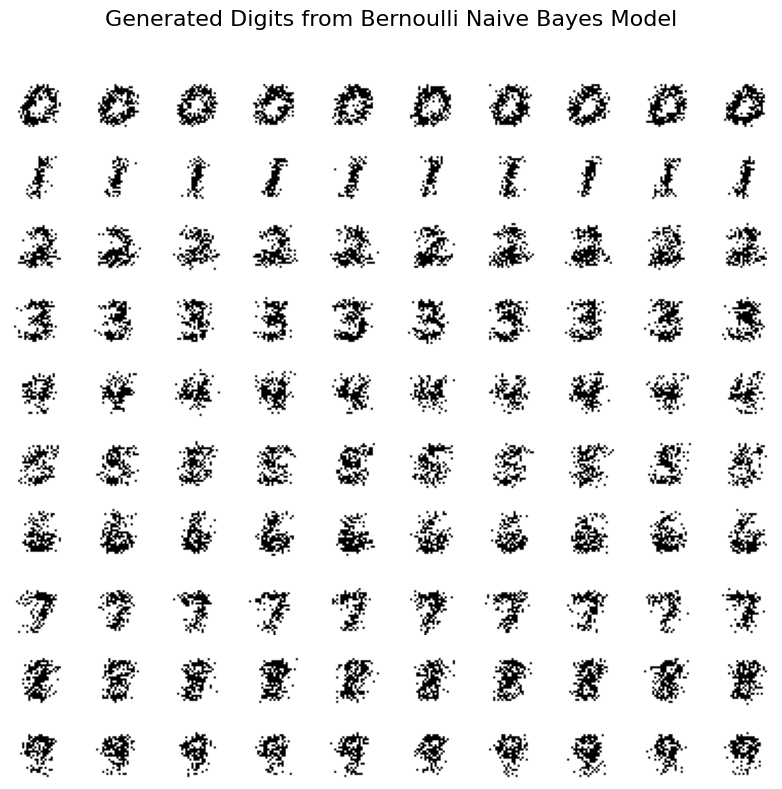

In [ ]:
def Q5(num_examples):

  ### STUDENT START ###
  # Train a Bernoulli Naive Bayes model. We'll use the full training set for better probability estimates, along with a good alpha from Q3 and a binarization threshold.
  print("\nTraining a Bernoulli Naive Bayes model on the full dataset...")
  model = BernoulliNB(alpha=0.01, binarize=0.1)
  model.fit(train_data.to_numpy(), train_labels)

  # Extract the learned probabilities for each pixel. The model stores log probabilities; we convert them back with np.exp().
  # The result is a (10, 784) array where each row corresponds to a digit and each column is the probability of that pixel being "on".
  class_probabilities = np.exp(model.feature_log_prob_)

  # Generate and plot the images in a 10x10 grid. Each row in the grid will show 10 generated examples of a single digit.
  fig, axes = plt.subplots(10, 10, figsize=(8, 8))

  for digit in range(10):  # For each digit class (0-9)
      for example in range(10):  # Generate 10 examples
          pixel_probs = class_probabilities[digit] # Get the probability vector for the current digit
          random_values = np.random.rand(784) # Generate 784 random numbers between 0 and 1
          new_image_flat = (random_values < pixel_probs).astype(int) # A pixel is set to 1 if its random number is less than its learned probability
          new_image_2d = new_image_flat.reshape(28, 28) # Reshape the 784-pixel vector into a 28x28 image
          # Plot the generated image
          ax = axes[digit, example]
          ax.imshow(new_image_2d, cmap='gray_r')
          ax.axis('off') # Hide the x and y axes

  fig.suptitle("Generated Digits from Bernoulli Naive Bayes Model", fontsize=16)
  plt.tight_layout(rect=[0, 0, 1, 0.96])
  plt.show()

  ### STUDENT END ###

Q5(10)

ANSWER:


— The generated images are recognizable but appear blurrier and noisier than the original training images.

— This occurs because the Bernoulli Naive Bayes model treats every pixel independently when generating an image.

— The model doesn't understand that neighboring pixels should be related, so it fails to create the clean, connected lines of actual handwriting.

In general, the model successfully learns the general probability map for each digit, but its inability to model the relationships
    between pixels prevents it from creating images with the same structure and clarity as the real training examples.

### Question 6: Model Calibration

---
Recall that:
 * a **strongly calibrated** classifier is rougly 90% accurate when it says it is 90% accurate. The model's estimated posterior probability of the predicted class is indeed 0.9.
 * A **weakly calibrated** classifier is more accurate when it "says" it is more accurate. The actual accuracy is higher when the model's estimated posterior probability is higher.
 * A **poorly calibrated** classifier has no positive correlation between the model's estimate posterior probability and the actual accuracy.

1. Produce a Bernoulli Naive Bayes model.  
1. Evaluate performance:
  1. Partition the dev set into several buckets based on the estimated posterior probabilities of the predicted classes (predict_proba)
    - Think of it as a bin in a histogram, where each bin groups a range of estimated posterior probabilities of the predicted classes (predict_proba).
    - Then estimate the actual accuracy the classifier achieved for each bucket.
    - So, for each prediction:
       - Find the bucket whose range includes the estimated posterior probability,
       - and update "correct" and "total" counters accordingly.
       - Show the accuracy for each bucket.
1. How would you characterize the calibration for this Bernoulli Naive Bayes model according to the definitions above?

Notes:
* Set LaPlace smoothing (alpha) to the optimal value (from question 3).
* Set binarization threshold to 0.
* Train on the mini train set.
* Evaluate perfromance on the dev set.



In [ ]:
def Q6(buckets, correct, total):
    """
    Evaluates the calibration of a trained Bernoulli Naive Bayes model.

    Args:
        buckets (list): A list of upper bounds for the probability buckets.
        correct (list): A list to store the count of correct predictions for each bucket.
        total (list): A list to store the total count of predictions for each bucket.
    """

    # Train the Bernoulli Naive Bayes model. Use the optimal alpha (0.001) from Q3 and the specified binarization threshold.
    model = BernoulliNB(alpha=0.001, binarize=0.0)
    model.fit(mini_train_data.to_numpy(), mini_train_labels)
    # Get predictions and probabilities for the dev set. predict_proba() gives the posterior probabilities for each class.
    probabilities = model.predict_proba(dev_data.to_numpy())

    # We need the probability of the predicted class, which is the max probability in each row.
    confidence_scores = np.max(probabilities, axis=1)
    predicted_labels = model.predict(dev_data.to_numpy())

    # Get the actual labels to check for correctness
    actual_labels = dev_labels.to_numpy()

    # Partitioning the results into buckets
    for i in range(len(predicted_labels)):
        confidence = confidence_scores[i]
        prediction_is_correct = (predicted_labels[i] == actual_labels[i])

        # Finding which bucket the confidence score falls into
        for bucket_index, upper_bound in enumerate(buckets):
            if confidence <= upper_bound:
                total[bucket_index] += 1
                if prediction_is_correct:
                    correct[bucket_index] += 1
                break # Move to the next prediction once the bucket is found

    # Showing the accuracy for each bucket
    print("\nModel Calibration Results:\n")
    print("{:<20} {:<25} {:<10}".format("Bucket", "Confidence Range", "Accuracy"))
    print("-" * 62)

    lower_bound = 0.0
    for i, upper_bound in enumerate(buckets):
        # Handle cases where a bucket has no predictions to avoid division by zero
        accuracy = 0.0 if total[i] == 0 else correct[i] / total[i]

        range_str = f"{lower_bound:.1f} < P <= {upper_bound}"
        accuracy_str = f"{accuracy:.4f} ({correct[i]}/{total[i]})"
        print("{:<20} {:<25} {:<10}".format(f"Bucket {i}", range_str, accuracy_str))
        lower_bound = upper_bound


# Define the buckets and initialize the counters for storing results
buckets = [0.5, 0.9, 0.999, 0.99999, 0.9999999, 0.999999999, 0.99999999999, 0.9999999999999, 1.0]
correct = [0 for i in buckets]
total = [0 for i in buckets]

Q6(buckets, correct, total)


Model Calibration Results:

Bucket               Confidence Range          Accuracy  
--------------------------------------------------------------
Bucket 0             0.0 < P <= 0.5            0.0000 (0/0)
Bucket 1             0.5 < P <= 0.9            0.3548 (11/31)
Bucket 2             0.9 < P <= 0.999          0.4328 (29/67)
Bucket 3             1.0 < P <= 0.99999        0.4576 (27/59)
Bucket 4             1.0 < P <= 0.9999999      0.6522 (30/46)
Bucket 5             1.0 < P <= 0.999999999    0.7742 (48/62)
Bucket 6             1.0 < P <= 0.99999999999  0.7879 (26/33)
Bucket 7             1.0 < P <= 0.9999999999999 0.7907 (34/43)
Bucket 8             1.0 < P <= 1.0            0.9378 (618/659)


ANSWER:

Our results show that the Bernoulli Naive Bayes model is weakly calibrated. This is because there is a positive correlation between the model's confidence and its performance: when its predicted probability increases, its actual accuracy also increases.

However, the model is not strongly calibrated (and consistently overconfident). In cases where the model is more than 99.9% confident, its true accuracy is significantly lower. Note that this discrepancy between high confidence and more modest actual accuracy is a known characteristic of Naive Bayes models.

### Question 7 EXTRA CREDIT: Feature generation
---
1. Design new features to see if you can produce a Bernoulli Naive Bayes model with better performance.
1. Show the accuracy of a model based on the original features and the accuracy of the model based on the new features.

**Note that improving results is actually hard.**

Here are a few ideas to get you started:
- Try summing or averaging the pixel values in each row.
- Try summing or averaging the pixel values in each column.
- Try summing or averaging the pixel values in each square block. (pick various block sizes)
- Try implementing [*maxpool*](https://computersciencewiki.org/index.php/Max-pooling_/_Pooling) features, taking a rolling maximum over sub-regions of a the image.
- In any case, you can either transform the original data or add new "features" to it.

Notes:
* Train on the mini train set (enhanced to comprise the new features).
* Evaulate performance on the dev set.
* Ensure that your code is well commented.

In [ ]:
def generate_block_sum_features(data, block_size=4):
    """Generates features from binarized sums of pixel blocks."""
    image_data = data.to_numpy()
    num_images = image_data.shape[0]
    new_dim = 28 // block_size
    new_features_dataset = np.zeros((num_images, new_dim * new_dim))
    threshold = (block_size ** 2) * 0.25  # Binarization threshold

    for i in range(num_images):
        image_2d = image_data[i].reshape(28, 28)
        new_feature_vector = []
        for r in range(0, 28, block_size):
            for c in range(0, 28, block_size):
                block_sum = np.sum(image_2d[r:r+block_size, c:c+block_size])
                new_feature_vector.append(1 if block_sum > threshold else 0)
        new_features_dataset[i] = new_feature_vector
    return new_features_dataset


def generate_row_col_features(data):
    """Generates features from binarized sums of rows and columns."""
    image_data = data.to_numpy()
    num_images = image_data.shape[0]
    new_features_dataset = np.zeros((num_images, 28 + 28))  # 56 features total

    for i in range(num_images):
        image_2d = image_data[i].reshape(28, 28)
        # Binarize sums by comparing to the mean value for that image
        row_sums = (np.sum(image_2d, axis=1) > np.mean(np.sum(image_2d, axis=1))).astype(int)
        col_sums = (np.sum(image_2d, axis=0) > np.mean(np.sum(image_2d, axis=0))).astype(int)
        new_features_dataset[i] = np.concatenate((row_sums, col_sums))
    return new_features_dataset


def Q7():
    """
    Compares BernoulliNB models using original, block sum, and row/col sum features.
    """
    # 1. Baseline Model (Original Features)
    model = BernoulliNB(alpha=0.01, binarize=0.1)
    model.fit(mini_train_data, mini_train_labels)
    baseline_acc = model.score(dev_data, dev_labels)
    print(f"1. Baseline Model Accuracy (784 features):      {baseline_acc:.4f}")

    # 2. Model with Block Sum Features
    train_block_features = generate_block_sum_features(mini_train_data)
    dev_block_features = generate_block_sum_features(dev_data)
    model.set_params(binarize=None) # Features are already binarized
    model.fit(train_block_features, mini_train_labels)
    block_acc = model.score(dev_block_features, dev_labels)
    print(f"2. Block Sum Feature Model Accuracy (49 features): {block_acc:.4f}")

    # 3. Model with Row & Column Sum Features
    train_row_col_features = generate_row_col_features(mini_train_data)
    dev_row_col_features = generate_row_col_features(dev_data)
    model.fit(train_row_col_features, mini_train_labels)
    row_col_acc = model.score(dev_row_col_features, dev_labels)
    print(f"3. Row/Col Sum Feature Model Accuracy (56 features): {row_col_acc:.4f}\n")

# Run the comparison
Q7()



1. Baseline Model Accuracy (784 features):      0.8300
2. Block Sum Feature Model Accuracy (49 features): 0.7260
3. Row/Col Sum Feature Model Accuracy (56 features): 0.6640



Summary:

**Overall Result**: Both new feature sets (Block Sum and Row/Col Sum) performed significantly worse than the baseline model that used the original 784 raw pixels.

**Core Problem**: The new features suffered from critical information loss. By simplifying the image data too aggressively, they discarded some details that the model needed to distinguish between similar digits.

**Specific Flaws**:

- The Block Sum method lost the specific structure of strokes within each block.
- The Row/Col Sum method lost crucial positional information by projecting the image onto its axes.

**Conclusion**: For this specific dataset and model, the raw pixel features were more informative than the simplified, engineered features, highlighting that successful feature engineering requires a careful balance between reducing complexity and preserving essential information.